#### Load environment variables

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## Tool Definition

Let's start by defining some simple tools that an email assistant will use with the `@tool` decorator:

In [2]:
from typing import Literal
from datetime import datetime
from pydantic import BaseModel
from langchain_core.tools import tool

@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"

@tool
def schedule_meeting(
    attendees: list[str], subject: str, duration_minutes: int, preferred_day: datetime, start_time: int
) -> str:
    """Schedule a calendar meeting."""
    # Placeholder response - in real app would check calendar and schedule
    date_str = preferred_day.strftime("%A, %B %d, %Y")
    return f"Meeting '{subject}' scheduled on {date_str} at {start_time} for {duration_minutes} minutes with {len(attendees)} attendees"

@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    # Placeholder response - in real app would check actual calendar
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"

@tool
class Done(BaseModel):
      """E-mail has been sent."""
      done: bool

## **Email Agent**

In [3]:
from langgraph.graph import MessagesState

class State(MessagesState):
    # We can add a specific key to our state for the email input
    email_input: dict
    classification_decision: Literal["ignore", "respond", "notify"]

#### Triage node

We define a python function with our triage routing logic.

For this, we use [structured outputs](https://python.langchain.com/docs/concepts/structured_outputs/) with a Pydantic model, which is particularly useful for defining structured output schemas because it offers type hints and validation. The descriptions in the pydantic model are important because they get passed as part JSON schema to the LLM to inform the output coercion.

In [4]:
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from langgraph.graph import END
from langgraph.types import Command
from prompts import triage_system_prompt, triage_user_prompt, default_triage_instructions, default_background
from utils import parse_email, format_email_markdown
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.environ["GROQ_API_KEY"]

In [5]:
class RouterSchema(BaseModel):
    """Analyze the unread email and route it according to its content."""
    reasoning: str = Field(
        description="Step by Step reasoning behind the classifications"
    )
    classifications: Literal["ignore", "respond", "notify"] = Field(
        description= """
        The classifications of an email: 'ignore' for irrelevant emails, 
        'notify' for important information that doesn't need a response,
        'respond' for emails that need to reply.
        """

    )

llm = init_chat_model(
    model_provider="groq",
    model="qwen/qwen3-32b",
    temperature=0.1
)
llm_router = llm.with_structured_output(RouterSchema)

In [6]:
class RouterSchema(BaseModel):
    """Analyze the unread email and route it according to its content."""

    reasoning: str = Field(
        description="Step-by-step reasoning behind the classification."
    )
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="The classification of an email: 'ignore' for irrelevant emails, "
        "'notify' for important information that doesn't need a response, "
        "'respond' for emails that need a reply",
    )

# Initialize the LLM for use with router / structured output
llm = init_chat_model("groq:qwen/qwen3-32b", temperature=0.0)
llm_router = llm.with_structured_output(RouterSchema) 

def triage_router(state: State) -> Command[Literal["response_agent", "__end__"]]:
    """Analyze email content to decide if we should respond, notify, or ignore."""
    
    author, to, subject, email_thread = parse_email(state["email_input"])
    system_prompt = triage_system_prompt.format(
        background=default_background,
        triage_instructions=default_triage_instructions
    )

    user_prompt = triage_user_prompt.format(
        author=author, to=to, subject=subject, email_thread=email_thread
    )

    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )
    
    if result.classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Respond to the email: \n\n{format_email_markdown(subject, author, to, email_thread)}",
                }
            ],
            "classification_decision": result.classification,
        }
        
    elif result.classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")
        goto = END
        update =  {
            "classification_decision": result.classification,
        }
        
    elif result.classification == "notify":
        print("🔔 Classification: NOTIFY - This email contains important information")
        # For now, we go to END. But we will add to this later!
        goto = END
        update = {
            "classification_decision": result.classification,
        }
        
    else:
        raise ValueError(f"Invalid classification: {result.classification}")
    return Command(goto=goto, update=update)

## ***Time to Build the Agent***

In [7]:
from prompts import agent_system_prompt, default_response_preferences, default_cal_preferences
from prompt_templates import AGENT_TOOLS_PROMPT

In [8]:
print(AGENT_TOOLS_PROMPT)


1. write_email(to, subject, content) - Send emails to specified recipients
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings where preferred_day is a datetime object
3. check_calendar_availability(day) - Check available time slots for a given day
4. Done - E-mail has been sent



In [9]:
tools = [write_email, schedule_meeting, check_calendar_availability, Done]

tools_by_name = {tool.name: tool for tool in tools}
print(tools_by_name)

{'write_email': StructuredTool(name='write_email', description='Write and send an email.', args_schema=<class 'langchain_core.utils.pydantic.write_email'>, func=<function write_email at 0x7a7178453d80>), 'schedule_meeting': StructuredTool(name='schedule_meeting', description='Schedule a calendar meeting.', args_schema=<class 'langchain_core.utils.pydantic.schedule_meeting'>, func=<function schedule_meeting at 0x7a7178451260>), 'check_calendar_availability': StructuredTool(name='check_calendar_availability', description='Check calendar availability for a given day.', args_schema=<class 'langchain_core.utils.pydantic.check_calendar_availability'>, func=<function check_calendar_availability at 0x7a7194578860>), 'Done': StructuredTool(name='Done', description='E-mail has been sent.', args_schema=<class 'langchain_core.utils.pydantic.Done'>, func=<class '__main__.Done'>)}


In [10]:
llm_with_tools = llm.bind_tools(tools, tool_choice="required")

def llm_call(state: State):
    """LLM decides wether to call a tool or not"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    {
                        "role": "system", "content": agent_system_prompt.format(
                            tools_prompt = AGENT_TOOLS_PROMPT,
                            background = default_background,
                            response_preferences = default_response_preferences,
                            call_preferences = default_cal_preferences
                        )
                    }
                ] + state["messages"]
            )
        ]
    }

## **Tool Handler Node**

In [11]:
def tool_handler(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        # extract the tool
        tool = tools_by_name[tool_call["name"]]

        # run it
        observation = tool.invoke(tool_call["args"])

        result.append(
            {
                "role": "tool",
                "content": observation,
                "tool_call_id": tool_call["id"]
            }
        )

    return {
        "messages": result
    }

## **Conditional Routing**

In [12]:
def should_continue(state: State) -> Literal["tool_handler", "__end__"]:
    """Route to tool handler, or end if Done tool called."""

    messages = state["messages"]
    last_message = messages[-1]

    if last_message.tool_calls:
        for tool_call in last_message.tool_calls:
            if tool_call["name"] == "Done":
                return "__end__"
            else:
                return tool_handler

## **Agent Graph**

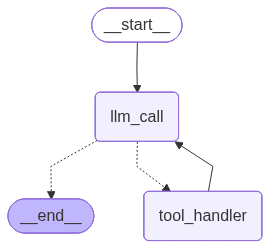

In [ ]:
from langgraph.graph import StateGraph, START, END
from utils import show_graph

overall_workflow = StateGraph(State)

overall_workflow.add_node("llm_call", llm_call)
overall_workflow.add_node("tool_handler", tool_handler)

## Add edges
overall_workflow.add_edge(START, "llm_call")
overall_workflow.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_handler": "tool_handler",
        "__end__": END
    }
)
overall_workflow.add_edge("tool_handler", "llm_call")
agent = overall_workflow.compile()
show_graph(agent)